## 0. Setup

In [1]:
import os, sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
warnings = __import__("warnings"); warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.dpi": 120})

In [2]:
sys.path.append(os.path.abspath(".."))
from src.user_genre_profile import (
    build_user_genre_profile,
    pivot_user_genre_profile,
    get_top_genres,
    save_user_genre_profile
)

In [3]:
PROJECT_ROOT  = os.path.abspath("..")
PROCESSED_DIR = os.path.join(PROJECT_ROOT, "data", "processed") + os.sep
SPLITS_DIR    = os.path.join(PROJECT_ROOT, "data", "splits")    + os.sep
FIGS_DIR      = os.path.join(PROJECT_ROOT, "results", "figures") + os.sep
os.makedirs(FIGS_DIR, exist_ok=True)

## 1. Load Data

In [5]:
# Load train ratings + cleaned movies (output from 02_preprocessing)
train  = pd.read_csv(SPLITS_DIR + "train.csv")
movies = pd.read_csv(PROCESSED_DIR + "movies_clean.csv")

print(f"Train ratings : {len(train):,}")
print(f"Movies        : {len(movies):,}")
display(train.head(3))
display(movies.head(3))


Train ratings : 1,565,182
Movies        : 87,585


,userId,movieId,rating,timestamp,datetime,year,month
0,1,2966,1.0,943226846,1999-11-21 23:27:26,1999,11
1,1,2997,4.0,943226846,1999-11-21 23:27:26,1999,11
2,1,2890,4.0,943226916,1999-11-21 23:28:36,1999,11


,movieId,title,genres,release_year,genre_list,no_genre,genre_Action,genre_Adventure,genre_Animation,genre_Children,...,genre_Horror,genre_IMAX,genre_Musical,genre_Mystery,genre_Romance,genre_Sci_Fi,genre_Thriller,genre_War,genre_Western,tag_profile
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,1995.0,"['Adventure', 'Animation', 'Children', 'Comedy...",False,0,1,1,1,...,0,0,0,0,0,0,0,0,0,children disney animation children disney disn...
1,2,Jumanji (1995),Adventure|Children|Fantasy,1995.0,"['Adventure', 'Children', 'Fantasy']",False,0,1,0,1,...,0,0,0,0,0,0,0,0,0,robin williams fantasy robin williams time tra...
2,3,Grumpier Old Men (1995),Comedy|Romance,1995.0,"['Comedy', 'Romance']",False,0,0,0,0,...,0,0,0,0,1,0,0,0,0,comedinha de velhinhos engraãƒâ§ada comedinha ...


## 2. Build User Genre Profile

Parameters:
- `liked_threshold = 3.5` — a movie is "liked" if rated ≥ 3.5★
- `blend_weight = 0.5`    — equal weight between weighted and liked score
- `top_n = 3`             — flag each user's top 3 genres


In [6]:
profile = build_user_genre_profile(
    ratings=train,
    movies=movies,
    liked_threshold=3.5,
    blend_weight=0.5,
    top_n=3
)

display(profile.head(10))
print(f"\nTotal (user, genre) pairs: {len(profile):,}")
print(f"Users: {profile['userId'].nunique():,} | Genres: {profile['genre'].nunique()}")


[build_user_genre_profile] Starting...
  Merged rows (ratings × genres): 1,565,182
  Users profiled : 12,773
  Genres tracked : 1069
[build_user_genre_profile] Done — shape: (775578, 8)


,userId,genre,avg_rating,weighted_score,liked_count,liked_score,combined_score,is_top_genre
0,1,"['Comedy', 'Drama', 'Romance']",3.777778,0.694444,7,1.000000,0.847222,True
1,1,['Comedy'],3.700000,0.675000,7,1.000000,0.837500,True
2,1,"['Drama', 'War']",4.125000,0.781250,6,0.857143,0.819196,True
3,1,['Drama'],3.416667,0.604167,6,0.857143,0.730655,False
4,1,"['Comedy', 'Crime', 'Drama']",5.000000,1.000000,2,0.285714,0.642857,False
5,1,"['Action', 'Adventure', 'Sci-Fi']",4.250000,0.812500,3,0.428571,0.620536,False
6,1,"['Action', 'Drama', 'War']",4.000000,0.750000,3,0.428571,0.589286,False
7,1,"['Crime', 'Drama']",4.000000,0.750000,3,0.428571,0.589286,False
8,1,"['Action', 'Adventure', 'Horror', 'Sci-Fi']",5.000000,1.000000,1,0.142857,0.571429,False
9,1,"['Action', 'Crime', 'Drama', 'Sci-Fi', 'Thrill...",5.000000,1.000000,1,0.142857,0.571429,False



Total (user, genre) pairs: 775,578
Users: 12,773 | Genres: 1069


## 3. Inspect a Single User's Profile

In [7]:
EXAMPLE_USER = train["userId"].iloc[0]  # pick first user in train

user_df = get_top_genres(profile, user_id=EXAMPLE_USER, n=10)
print(f"Top genres for user {EXAMPLE_USER}:")
display(user_df)


Top genres for user 1:


,genre,avg_rating,weighted_score,liked_count,liked_score,combined_score
0,"['Comedy', 'Drama', 'Romance']",3.777778,0.694444,7,1.000000,0.847222
1,['Comedy'],3.700000,0.675000,7,1.000000,0.837500
2,"['Drama', 'War']",4.125000,0.781250,6,0.857143,0.819196
3,['Drama'],3.416667,0.604167,6,0.857143,0.730655
4,"['Comedy', 'Crime', 'Drama']",5.000000,1.000000,2,0.285714,0.642857
5,"['Action', 'Adventure', 'Sci-Fi']",4.250000,0.812500,3,0.428571,0.620536
6,"['Action', 'Drama', 'War']",4.000000,0.750000,3,0.428571,0.589286
7,"['Crime', 'Drama']",4.000000,0.750000,3,0.428571,0.589286
8,"['Action', 'Adventure', 'Horror', 'Sci-Fi']",5.000000,1.000000,1,0.142857,0.571429
9,"['Action', 'Crime', 'Drama', 'Sci-Fi', 'Thrill...",5.000000,1.000000,1,0.142857,0.571429


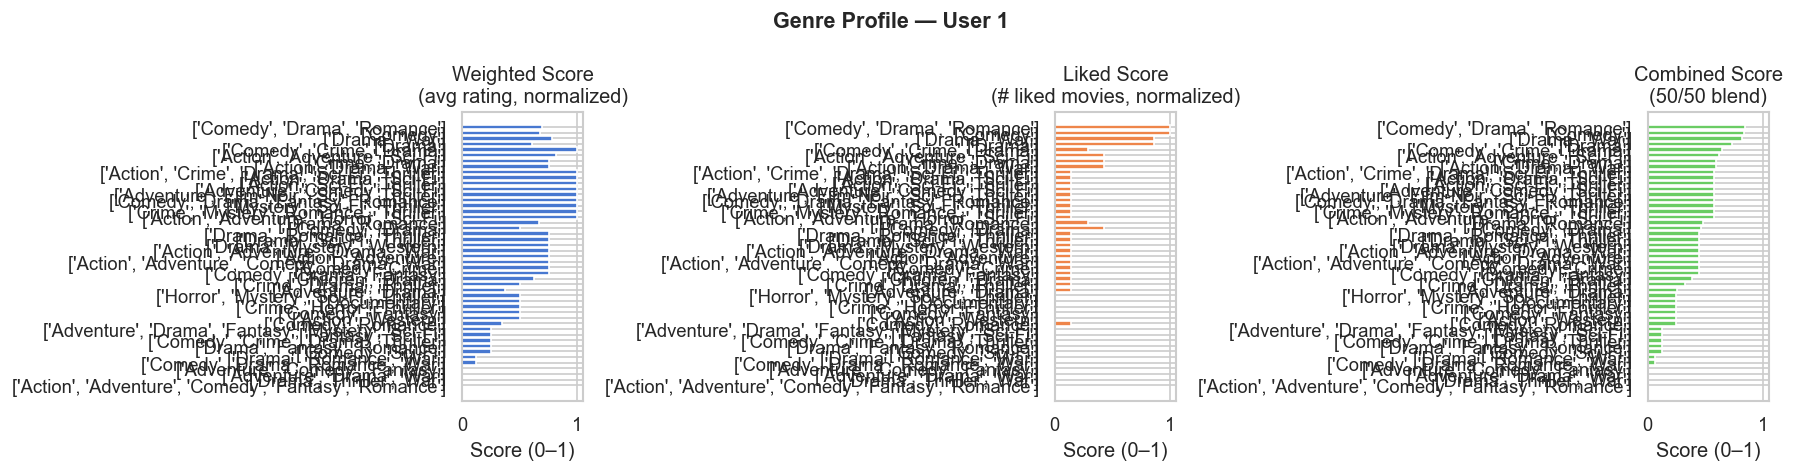

In [8]:
# Bar chart for the example user
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

user_full = profile[profile["userId"] == EXAMPLE_USER].sort_values("combined_score", ascending=True)

for ax, col, title, color in zip(
    axes,
    ["weighted_score", "liked_score", "combined_score"],
    ["Weighted Score\n(avg rating, normalized)", "Liked Score\n(# liked movies, normalized)", "Combined Score\n(50/50 blend)"],
    sns.color_palette("muted")[:3]
):
    ax.barh(user_full["genre"], user_full[col], color=color)
    ax.set_xlim(0, 1.05)
    ax.set_title(title)
    ax.set_xlabel("Score (0–1)")

plt.suptitle(f"Genre Profile — User {EXAMPLE_USER}", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(FIGS_DIR + "user_genre_profile_example.png")
plt.show()


## 4. Global Genre Preference Across All Users

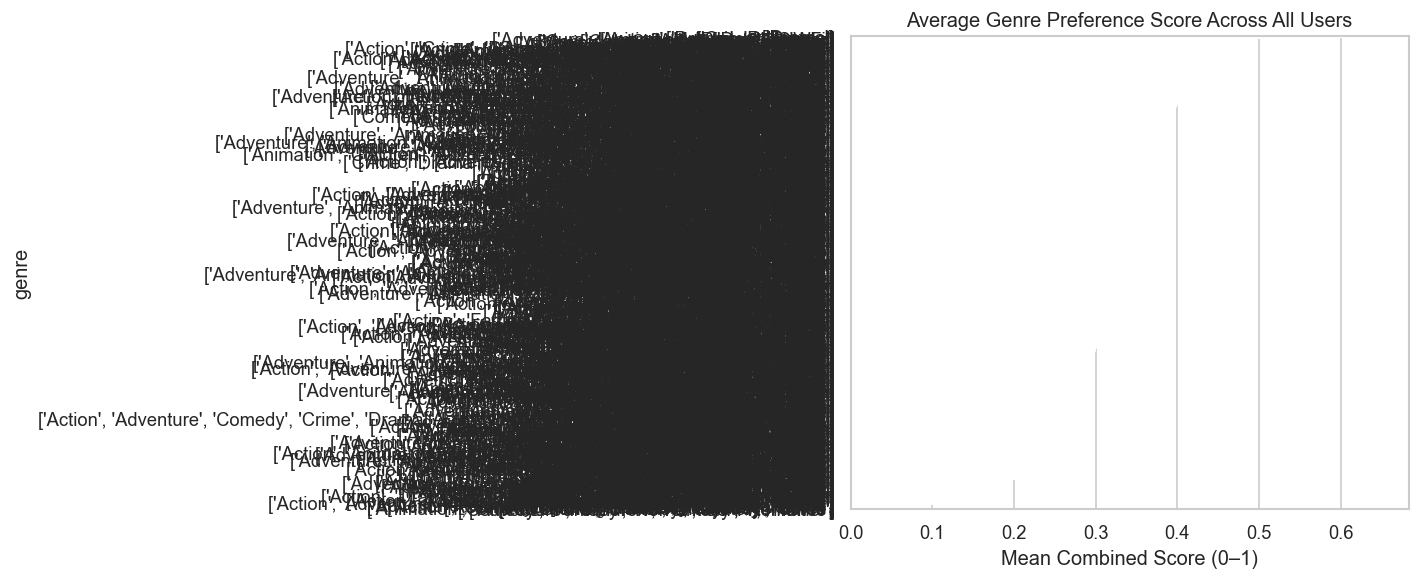

,genre,combined_score
0,['Drama'],0.650453
1,"['Crime', 'Drama']",0.607588
2,"['Drama', 'Romance']",0.533546
3,"['Adventure', 'Animation', 'Drama', 'Horror']",0.514633
4,"['Action', 'Adventure', 'Sci-Fi']",0.511686
...,...,...
1064,"['Adventure', 'Children', 'Comedy', 'Sci-Fi']",0.079060
1065,"['Animation', 'Crime', 'Drama', 'Fantasy', 'My...",0.055556
1066,"['Adventure', 'Crime', 'Drama', 'Romance']",0.040278
1067,"['Comedy', 'Fantasy', 'Horror', 'Sci-Fi', 'Thr...",0.000000


In [9]:
# Average combined score per genre across all users
global_genre = (
    profile.groupby("genre")["combined_score"]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

plt.figure(figsize=(12, 5))
sns.barplot(data=global_genre, x="combined_score", y="genre", palette="muted")
plt.title("Average Genre Preference Score Across All Users")
plt.xlabel("Mean Combined Score (0–1)")
plt.tight_layout()
plt.savefig(FIGS_DIR + "global_genre_preference.png")
plt.show()

display(global_genre)


## 5. Genre Preference Heatmap (Sample of Users)

[pivot_user_genre_profile] Shape: (12773, 1069)


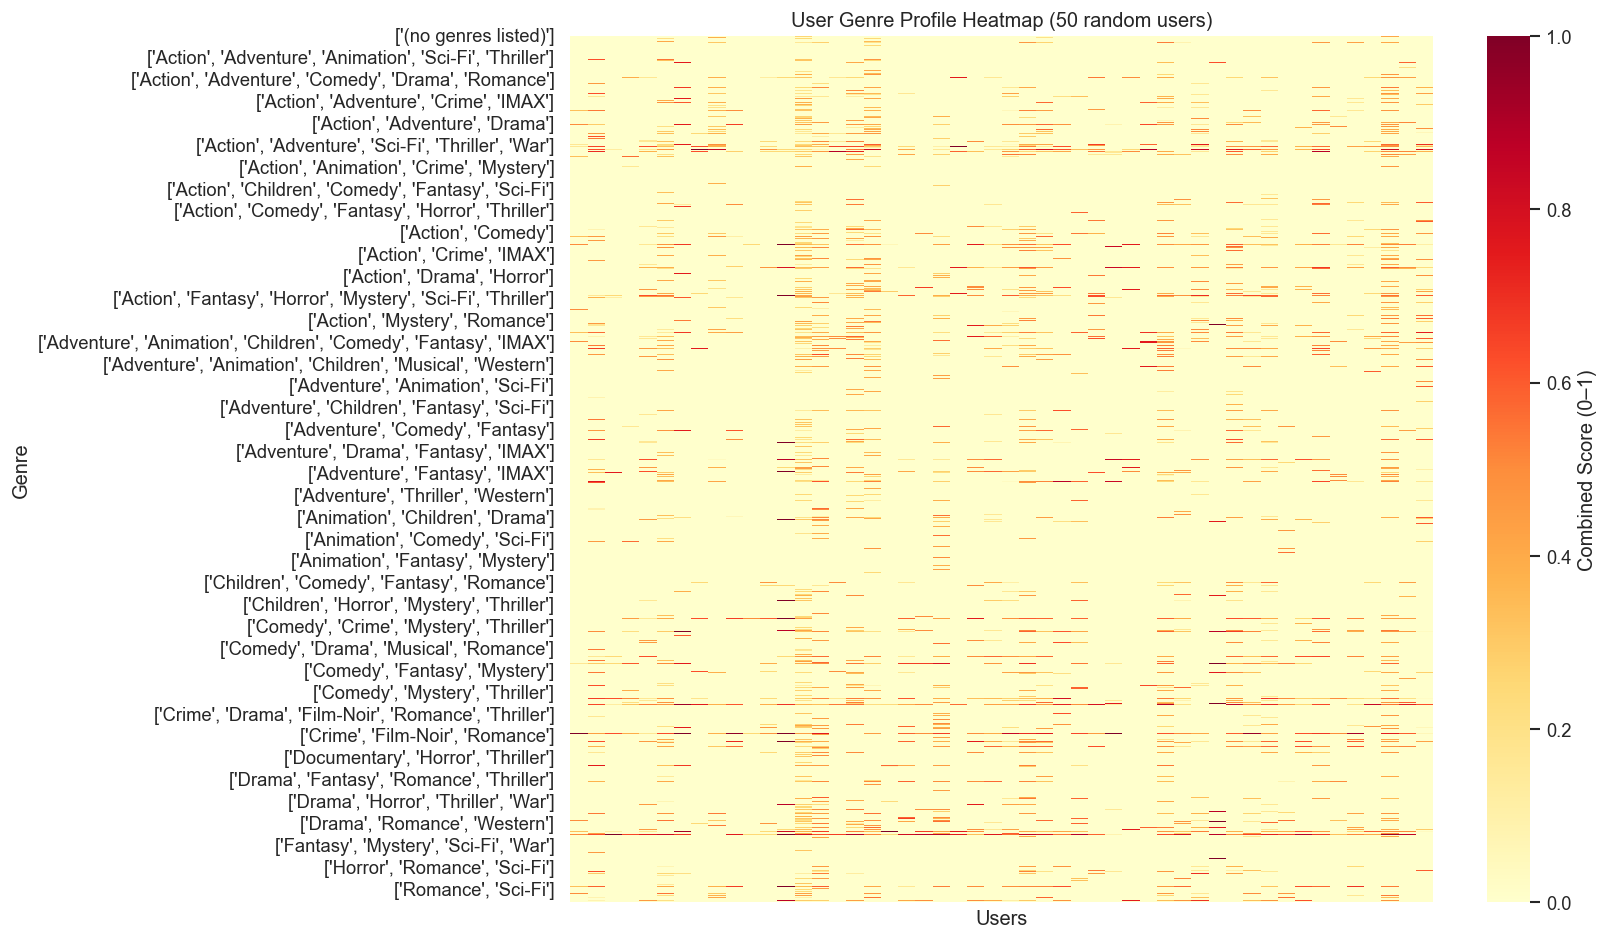

In [10]:
# Wide-format pivot
profile_wide = pivot_user_genre_profile(profile, score_col="combined_score")

# Sample 50 users for visualization
sample_users = profile_wide.sample(min(50, len(profile_wide)), random_state=42)

plt.figure(figsize=(14, 8))
sns.heatmap(
    sample_users.T,
    cmap="YlOrRd",
    linewidths=0.0,
    cbar_kws={"label": "Combined Score (0–1)"},
    xticklabels=False
)
plt.title("User Genre Profile Heatmap (50 random users)")
plt.xlabel("Users")
plt.ylabel("Genre")
plt.tight_layout()
plt.savefig(FIGS_DIR + "user_genre_heatmap.png")
plt.show()


## 6. Most Common Top Genres Across Users

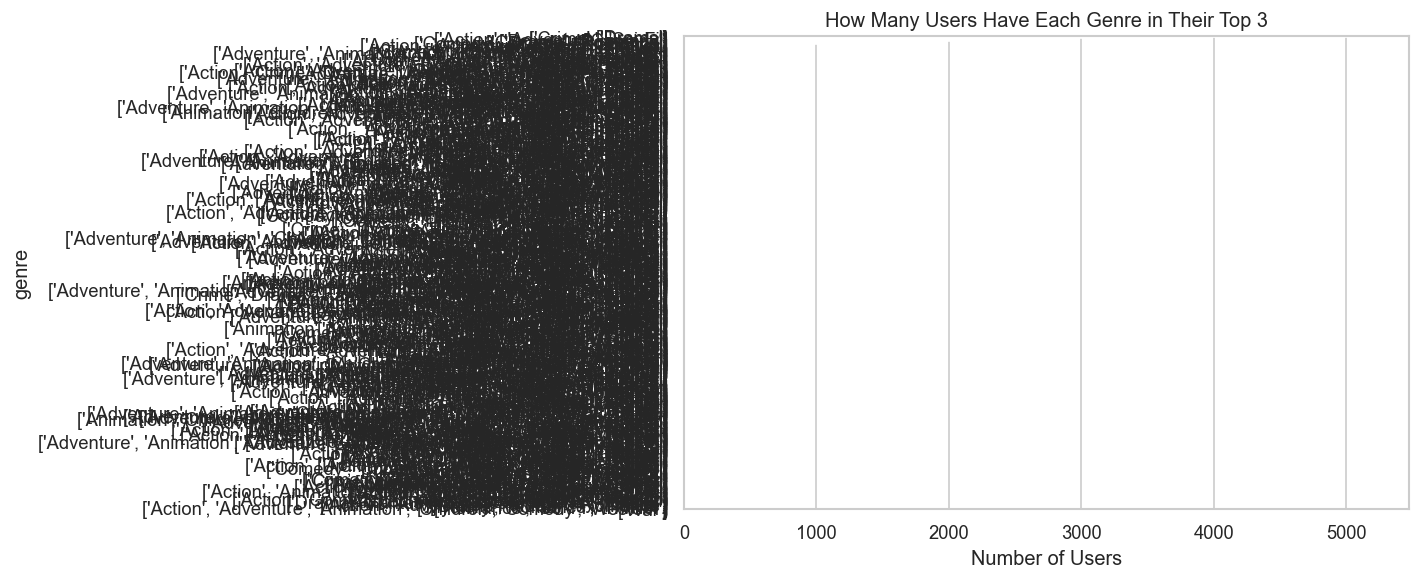

,genre,num_users
0,['Drama'],5212
1,"['Crime', 'Drama']",3198
2,"['Action', 'Adventure', 'Sci-Fi']",2784
3,['Comedy'],2671
4,"['Drama', 'Romance']",2070
...,...,...
498,"['Drama', 'Horror', 'Romance']",1
499,"['Mystery', 'Romance', 'Thriller']",1
500,"['Romance', 'Sci-Fi', 'Thriller']",1
501,"['Action', 'Adventure', 'Animation', 'Children...",1


In [11]:
# Which genre appears most as someone's #1 favourite?
top1 = (
    profile[profile["is_top_genre"]]
    .groupby("genre")["userId"]
    .count()
    .sort_values(ascending=False)
    .reset_index()
    .rename(columns={"userId": "num_users"})
)

plt.figure(figsize=(12, 5))
sns.barplot(data=top1, x="num_users", y="genre", palette="muted")
plt.title("How Many Users Have Each Genre in Their Top 3")
plt.xlabel("Number of Users")
plt.tight_layout()
plt.savefig(FIGS_DIR + "top_genre_distribution.png")
plt.show()

display(top1)


## 7. Score Distribution Analysis

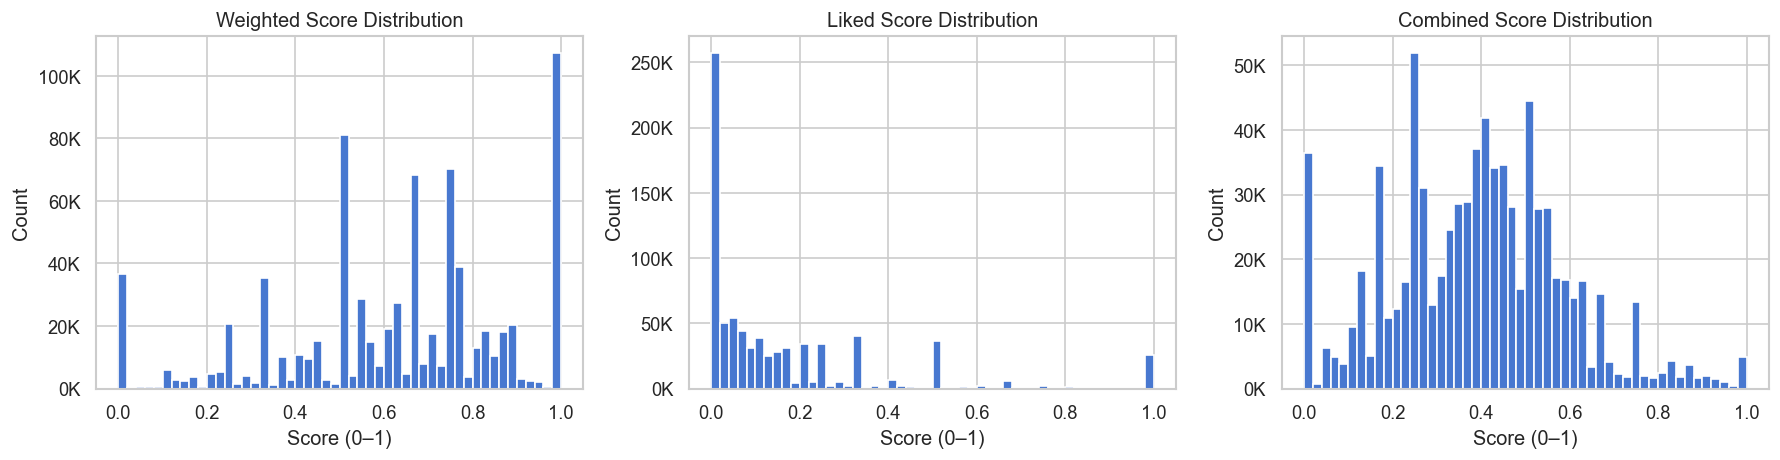

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col, title in zip(
    axes,
    ["weighted_score", "liked_score", "combined_score"],
    ["Weighted Score", "Liked Score", "Combined Score"]
):
    ax.hist(profile[col], bins=50, color=sns.color_palette("muted")[0], edgecolor="white")
    ax.set_title(f"{title} Distribution")
    ax.set_xlabel("Score (0–1)")
    ax.set_ylabel("Count")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e3:.0f}K"))

plt.tight_layout()
plt.savefig(FIGS_DIR + "genre_score_distributions.png")
plt.show()


## 8. Save Profile

In [13]:
save_user_genre_profile(profile, processed_dir=PROCESSED_DIR)

# Also save wide format
profile_wide = pivot_user_genre_profile(profile)
profile_wide.to_csv(PROCESSED_DIR + "user_genre_profile_wide.csv")
print("Saved wide format to:", PROCESSED_DIR + "user_genre_profile_wide.csv")


[save] Saved to d:\DataMining\722I0004_523V0015_523K0078_midterm_DataMining\data\processed\user_genre_profile.csv
[pivot_user_genre_profile] Shape: (12773, 1069)
Saved wide format to: d:\DataMining\722I0004_523V0015_523K0078_midterm_DataMining\data\processed\user_genre_profile_wide.csv


## 9. Summary & How This Will Be Used

| Output file | Description |
|---|---|
| `user_genre_profile.csv` | Long format — one row per (user, genre) with all scores |
| `user_genre_profile_wide.csv` | Wide format — users as rows, genres as columns |

**How this feeds into recommendation:**

- **Content-based filtering** — match a user's top genres against movie genres to boost relevant movies
- **Hybrid model** — use genre affinity as an additional signal on top of CF scores
- **Cold-start** — for new users with few ratings, genre preference gives an immediate fallback
- **Explainability** — "We recommended this because you love Film-Noir"
